# Unicycle drop + north motion

This notebook runs a MuJoCo simulation using the existing `VideoSim` wrapper. The unicycle starts at 1 m height, drops to a ground clamp, then drives 1 m to the north (positive y).

Outputs:
- MP4 video saved to `videos/unicycle_fall_north.mp4`.
- Three separate acceleration plots ($a_x$, $a_y$, $a_z$).

In [15]:
from __future__ import annotations

from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Resolve project root for imports (assumes notebook runs from mcav_project/notebooks).
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.simulation.video_sim import VideoSim
from src.utils.config import load_config

In [16]:
config = str(ROOT / "config/unicycle_fall_north.yaml")

In [17]:
class UnicycleDropNorthSim(VideoSim):
    def __init__(self, config: dict):
        super().__init__(config)

        if self.model.nq < 7 or self.model.nv < 6:
            raise RuntimeError("Model needs a free root joint (nq>=7, nv>=6).")

        self.start_z = 1.0
        self.north_speed = 0.5
        self.target_north = 1.0

        # Initialize pose.
        # Face North (+Y axis) -> rotate 90 degrees around Z axis.
        # MuJoCo quaternions are [w, x, y, z]
        qw = np.cos(np.pi / 4)
        qz = np.sin(np.pi / 4)
        self.data.qpos[:7] = np.array([0.0, 0.0, self.start_z, qw, 0.0, 0.0, qz])
        self.data.qvel[:6] = 0.0

        self.landed = False
        self.reached = False
        self.start_y = float(self.data.qpos[1])
        self.target_y = self.start_y + self.target_north

    def _loop_step(self, t: float, step: int):
        qpos = self.data.qpos
        qvel = self.data.qvel
        qacc = self.data.qacc

        # Detect landing: wait until z-velocity is near zero and we are near the floor.
        if not self.landed and qpos[2] < 0.2 and abs(qvel[2]) < 0.01:
            self.landed = True

        # Start moving north after landing without a clamping hack.
        if self.landed and not self.reached:
            # We inject a constant vertical override if we just want pure kinematics,
            # but allowing true contact is better. Here we just set the global y velocity.
            # Since we rotated to face +Y, global +Y is now our forward direction!
            qvel[1] = self.north_speed
            if qpos[1] >= self.target_y:
                qvel[:3] = 0.0
                self.reached = True

        self.logger.log({
            "x": float(qpos[0]),
            "y": float(qpos[1]),
            "z": float(qpos[2]),
            "vx": float(qvel[0]),
            "vy": float(qvel[1]),
            "vz": float(qvel[2]),
            "ax": float(qacc[0]),
            "ay": float(qacc[1]),
            "az": float(qacc[2]),
            "landed": bool(self.landed),
            "reached": bool(self.reached),
        })

In [18]:
import pandas as pd
pd.set_option('display.float_format', '{:.2e}'.format)

sim = UnicycleDropNorthSim(config)
sim.run()
df = sim.to_dataframe()
df.tail()

Simulation: 100%|██████████| 800/800 [00:00<00:00, 1917.01step/s]


Video saved → /Users/vi/Documents/Projects/AUCT/RoboticProject/mcav_project/videos/unicycle_fall_north.mp4


,x,y,z,vx,vy,vz,ax,ay,az,landed,reached,t
795,7.02e-13,1.23e+00,1.50e-01,7.71e-16,1.67e-01,1.60e-15,1.31e-15,-9.37e-16,3.53e-16,True,True,3.98e+00
796,7.02e-13,1.23e+00,1.50e-01,7.64e-16,1.67e-01,1.60e-15,-1.38e-15,-1.45e-15,2.52e-16,True,True,3.98e+00
797,7.02e-13,1.24e+00,1.50e-01,7.62e-16,1.67e-01,1.60e-15,-5.19e-16,-1.13e-15,3.54e-16,True,True,3.98e+00
798,7.02e-13,1.24e+00,1.50e-01,7.55e-16,1.67e-01,1.60e-15,-1.27e-15,-1.45e-15,4.67e-17,True,True,3.99e+00
799,7.02e-13,1.24e+00,1.50e-01,7.46e-16,1.67e-01,1.60e-15,-1.85e-15,-2.16e-16,4.52e-16,True,True,4.00e+00


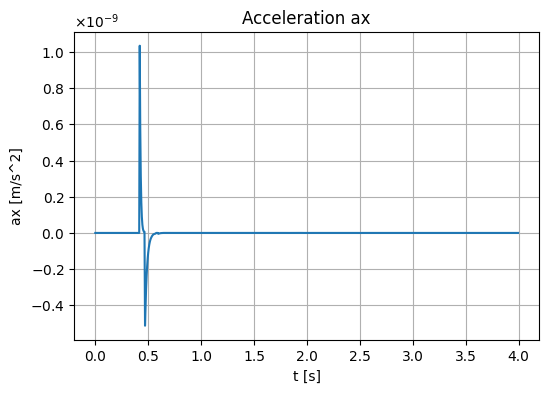

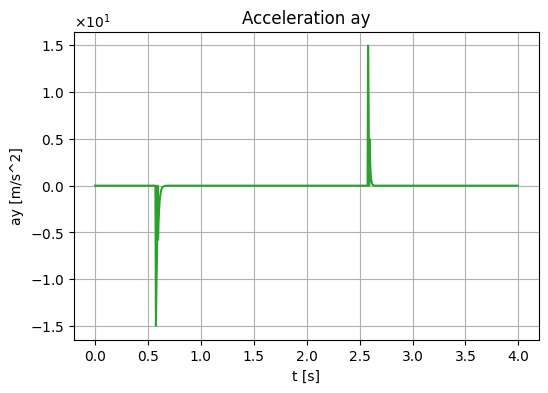

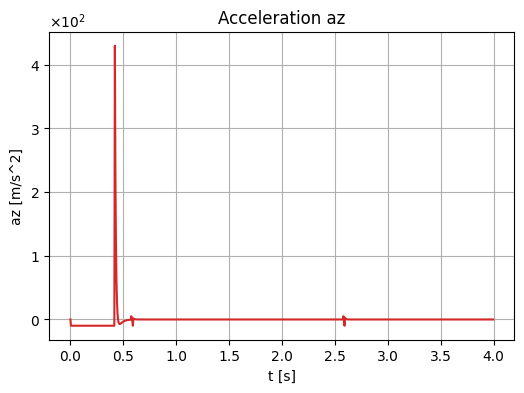

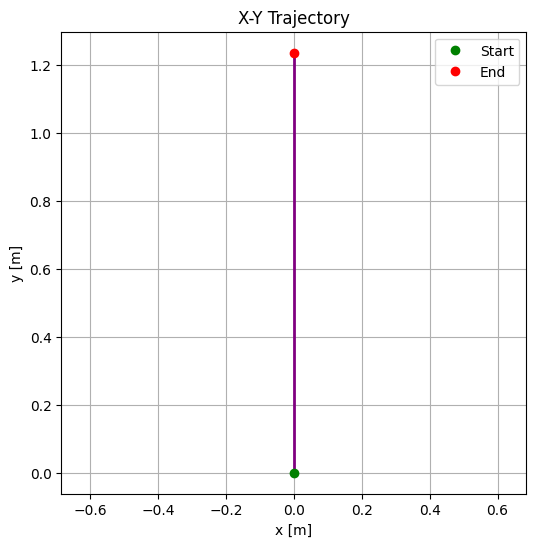

In [19]:
from matplotlib.ticker import ScalarFormatter

plt.figure(figsize=(6, 4))
plt.plot(df["t"], df["ax"], color="#1f77b4")
plt.xlabel("t [s]")
plt.ylabel("ax [m/s^2]")
plt.title("Acceleration ax")
plt.grid(True)
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(df["t"], df["ay"], color="#2ca02c")
plt.xlabel("t [s]")
plt.ylabel("ay [m/s^2]")
plt.title("Acceleration ay")
plt.grid(True)
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(df["t"], df["az"], color="#d62728")
plt.xlabel("t [s]")
plt.ylabel("az [m/s^2]")
plt.title("Acceleration az")
plt.grid(True)
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(df["x"], df["y"], color="purple", linewidth=2)
plt.plot(df["x"].iloc[0], df["y"].iloc[0], 'go', label="Start")
plt.plot(df["x"].iloc[-1], df["y"].iloc[-1], 'ro', label="End")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("X-Y Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()